In [20]:
import h5py
import numpy as np
import scipy as sp
from scipy.sparse.linalg import norm
import matplotlib.pyplot as plt
import openfermion as of
from openfermionpyscf import run_pyscf
import qiskit
from quimb_tebd import (
    pauli_sum_to_mpo, get_drmg_ground_state, trotter_circuit_from_psum,
    energy_vs_d, get_evolved_states, fill_subspace_matrices_mps,
    exact_evolved_states, mps_to_vector, fill_subspace_matrices_vectors
)


In [15]:
molec = "LiH"
basis = "sto-3g"
n_elec = 4
geometry = of.chem.geometry_from_pubchem(molec)
multiplicity = 1
dmrg_max_bond = [5, 7, 10]
tebd_max_bond = [5, 7, 10]
mpo_max_bond = 500
steps = 10
eps = 1e-12
d = 15

In [ ]:
# Get the Hamiltonian.
molecule = of.chem.MolecularData(
    geometry, basis, multiplicity
)
molecule = run_pyscf(molecule, run_scf=1, run_fci=1)
print(f"HF energy:", molecule.hf_energy)
print(f"FCI energy:", molecule.fci_energy)
hamiltonian = molecule.get_molecular_hamiltonian()
hamiltonian_qubop = of.transforms.jordan_wigner(hamiltonian)
hamiltonian_psum = of.transforms.qubit_operator_to_pauli_sum(hamiltonian_qubop)
ham_sparse = of.linalg.get_sparse_operator(hamiltonian_qubop)
qs = hamiltonian_psum.qubits
hamiltonian_mpo = pauli_sum_to_mpo(hamiltonian_psum, qs, mpo_max_bond)


HF energy: -7.767362135748557
FCI energy: -7.784460280031223


In [17]:
ham_norm = norm(ham_sparse)
tau = np.pi / ham_norm
print(f"tau = {tau:4.5e}")

tau = 1.12750e-02


In [18]:
# Run DMRG
ground_states = []
dmrg_energies = []
for i, chi_dmrg in enumerate(dmrg_max_bond):
    ground_state, energy, number = get_drmg_ground_state(hamiltonian_mpo, n_elec, chi_dmrg)
    ground_states.append(ground_state.copy())
    dmrg_energies.append(energy)
    print(f"DMRG ground state has energy {energy} and occupation {number}.")

DMRG ground state has energy -7.618400545235117 and occupation 4.000000000562759.
DMRG ground state has energy -7.618566780371529 and occupation 4.000000190770078.
DMRG ground state has energy -7.618574061314481 and occupation 4.000000252317274.


In [19]:
# Do TEBD Krylov with the DMRG reference state.
ev_circuit = trotter_circuit_from_psum(hamiltonian_psum, tau, steps)
ev_circuit_transpiled = qiskit.transpile(ev_circuit, basis_gates=["u3", "cx"])
tebd_energies = np.zeros((len(tebd_max_bond), d-1), dtype=float)
tebd_all_h = np.zeros((len(tebd_max_bond), d, d), dtype=complex)
tebd_all_s = np.zeros((len(tebd_max_bond), d, d), dtype=complex)
bond_sizes = np.zeros((len(tebd_max_bond), d, len(hamiltonian_mpo.tensors)-1), dtype=int)
for i, chi_tebd in enumerate(tebd_max_bond):
    print(f"chi_tebd = {chi_tebd}")
    states = get_evolved_states(ev_circuit_transpiled, ground_states[0].copy(), d, chi_tebd, None)
    for j, state in enumerate(states):
        bond_sizes[i, j, :] = state.bond_sizes()
    h, s = fill_subspace_matrices_mps(states, hamiltonian_mpo)
    energies, num_kept = energy_vs_d(h, s, method="threshold", eps=eps)
    tebd_energies[i, :] = energies
    tebd_all_h[i, :, :] = h
    tebd_all_s[i, :, :] = s


chi_tebd = 5
chi_tebd = 7
chi_tebd = 10


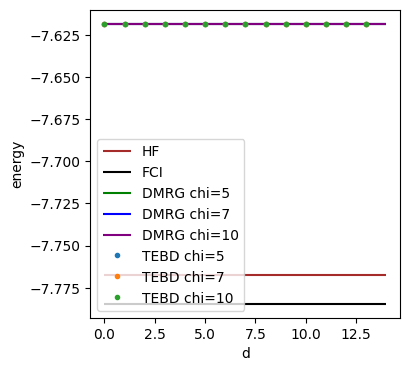

In [22]:
fig2, ax2 = plt.subplots(1, 1, figsize=(4, 4))
ax2.hlines(molecule.hf_energy, 0., tebd_energies.shape[1], colors=["brown"], label="HF")
ax2.hlines(molecule.fci_energy, 0., tebd_energies.shape[1], colors=["black"], label="FCI")
dmrg_colors = ["green", "blue", "purple"]
for i, (chi, dmrg_energy) in enumerate(zip(dmrg_max_bond, dmrg_energies)):
    ax2.hlines(dmrg_energy, 0., tebd_energies.shape[1], dmrg_colors[i], label=f"DMRG chi={chi}")
for i, chi in enumerate(tebd_max_bond):
    ax2.plot(tebd_energies[i, :], '.', label=f"TEBD chi={chi}")
ax2.set_ylabel("energy")
ax2.set_xlabel("d")
ax2.legend(loc="lower left")